## Imports

In [1]:
import argparse
import os
import numpy as np
from typing import Tuple
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Topic 1: Transportation and delivery schedulin (MLP)

## Dataset Preporation

### Сore geometry and routing functions

In [6]:
def dist(a,b):
  #Eucledean distance between two 2D points.
  return float(np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2))

In [9]:
def nn_route_length(depot, pts):
  #Nearest-neighbor routing length
  #depot -> all points -> depot
  if len(pts) == 0:
    return 0.0

  unvisited = pts.copy()
  cur = depot
  total_len = 0.0

  while unvisited:
    idx = min(
        range(len(unvisited)),
        key=lambda i: dist(cur, unvisited[i])
    )
    nxt = unvisited.pop(idx)
    total_len += dist(cur, nxt)
    cur = nxt

  total_len += dist(cur, depot)
  return total_len

In [16]:
#Test NN-routing on a known example
depot = (0, 0)
pts = [(1,0), (0,1), (1,1)]

nn_route_length(depot, pts)

4.0

### Brute-force optimal assignment

In [12]:
def best_assignment_two_courriers(depot, points_xy):
  """ Enumerate all 2^n assigments and finds the one minimizing
  the makespan under NN routing.
  Returns: best_makespan, best_mask, route_len_A, route_len_B"""

  N = len(points_xy)
  best = None

  for mask in range(1 << N):
    A = [points_xy[i] for i in range(N) if ((mask >> i) & 1) == 0]
    B = [points_xy[i] for i in range(N) if ((mask >> i) & 1) == 1]

    LA = nn_route_length(depot, A)
    LB = nn_route_length(depot, B)
    makespan = max(LA, LB)

    if best is None or makespan < best[0]:
      best = (makespan, mask, LA, LB)

  return best


In [17]:
pts = [(1,0), (0,1), (1,1), (2,0)]
best_assignment_two_courriers((0,0), pts)

(4.0, 6, 4.0, 3.414213562373095)

### Dataset Generation 

In [13]:
#Dataset generation
def make_dataset(num_samples, N, seed, low=0.0, high=2.0):
  """ Generates (X, y) dataset.
  X shape: (num_samples, 2N)
  y shape: (num_samples, N)"""
  rng = np.random.default_rng(seed)
  depot = (0.0, 0.0)

  X = np.zeros((num_samples, 2 * N), dtype = np.float32)
  y = np.zeros((num_samples, N), dtype=np.int64)

  for s in range(num_samples):
    pts = rng.uniform(low=low, high=high, size=(N,2)).astype(np.float32)

    best_makespan, best_mask, _, _ = best_assignment_two_courriers(
        depot, pts.tolist()
    )

    X[s] = pts.reshape(-1)
    for i in range(N):
      y[s, i] = (best_mask >> i) & 1

  return X, y

In [20]:
#generate a tiny dataset for sanity check
""" This cell verifies that the dataset generator
produces correctly shaped inputs and optimal binary
courier assignments, and that the assignments are geometrically
consistent with makespan minimization."""
X, y = make_dataset(num_samples=5, N=4, seed=42)
X,y

(array([[1.5479121 , 0.8777569 , 1.7171959 , 1.394736  , 0.1883547 ,
         1.9512447 , 1.5222794 , 1.5721287 ],
        [0.25622725, 0.90077186, 0.74159604, 1.8535299 , 1.2877302 ,
         1.6455232 , 0.8868284 , 0.45447743],
        [1.1091696 , 0.12763451, 1.6552624 , 1.2633288 , 1.5161755 ,
         0.7090519 , 1.941396  , 1.7862422 ],
        [1.556767  , 0.38927743, 0.933442  , 0.08760753, 0.308579  ,
         1.3660979 , 1.4895244 , 1.9350195 ],
        [0.6516507 , 0.7409194 , 0.93911165, 0.37894273, 0.25984302,
         0.9514099 , 0.4538187 , 1.339628  ]], dtype=float32),
 array([[0, 0, 1, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 0],
        [1, 1, 0, 0]]))

### Splitting the dataset

In [14]:
#Train/Valid/ Test split

def split_dataset(X, y, seed, ratios=(0.8, 0.1, 0.1)):
  #Splits dataset into train/val/test

  assert abs(sum(ratios) - 1.0) < 1e-6

  rng = np.random.default_rng(seed)
  idx = rng.permutation(len(X))

  n_train = int(ratios[0] * len(X))
  n_val = int(ratios[1] * len(X))

  train_idx = idx[:n_train]
  val_idx = idx[n_train:n_train + n_val]
  test_idx = idx[n_train + n_val:]

  return (
      X[train_idx], y[train_idx],
      X[val_idx], y[val_idx],
      X[test_idx], y[test_idx]
  )

In [22]:
#split check
X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(X,y, seed=42)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(4, 8) (4, 4)
(0, 8) (0, 4)
(1, 8) (1, 4)


### Dataset generation Final 

In [15]:
#Save dataset to .npz

def save_npz(path, X_train, y_train, X_val, y_val, X_test, y_test, meta):
  #Saves dataset splits and metadata to .npz

  np.savez (
      path,
      X_train=X_train,
      y_train=y_train,
      X_val=X_val,
      y_val=y_val,
      X_test=X_test,
      y_test=y_test,
      meta=meta
  )

In [ ]:
#Full dataset generation (final)
X, y = make_dataset(num_samples=5000, N=8, seed=0)

X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(X, y, seed=0)

save_npz("./dataset",
         X_train, y_train,
         X_val, y_val,
         X_test, y_test,
         meta= {
             "N": 8,
             "seed": 0,
             "num_samples": 5000,
             "coord_low": 0.0,
             "coord_high": 2.0
         })

## Model and Training

### Loading prepared Dataset

In [25]:
data = np.load("./dataset.npz", allow_pickle=True)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

meta = data["meta"].item()
N = meta["N"]

X_train.shape, y_train.shape

# converting data to pytorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# creating data loaders
batch_size = 64

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False
)

### MLP Model

In [26]:
class CourierAssignmentMLP(nn.Module):
    # input:  2N floats - coordinates
    # output: N sigmoid probabilities - courier B assignment
    def __init__(self, N):
        super().__init__()
        input_dim = 2 * N
        output_dim = N
        hidden_size = 256 # will improve the model performance

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(hidden_size, output_dim)
        )

    def forward(self, x):
        return self.net(x)
    
# instantiating model
model = CourierAssignmentMLP(N).to(device)

# parameter count
num_params = sum(p.numel() for p in model.parameters())
num_params

# loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)

### Training loop with validation and early stopping

In [27]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    max_epochs=100,
    patience=10
):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    for epoch in range(max_epochs):

        # training
        model.train()
        total_train_loss = 0.0
        correct_bits = 0
        total_bits = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * xb.size(0)

            # bit accuracy
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct_bits += (preds == yb).sum().item()
            total_bits += yb.numel()

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_acc = correct_bits / total_bits
        
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)

        # validation
        model.eval()
        total_val_loss = 0.0
        correct_bits = 0
        total_bits = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                logits = model(xb)
                loss = criterion(logits, yb)
                total_val_loss += loss.item() * xb.size(0)
                preds = (torch.sigmoid(logits) > 0.5).float()
                correct_bits += (preds == yb).sum().item()
                total_bits += yb.numel()

        avg_val_loss = (
            total_val_loss / len(val_loader.dataset)
            if len(val_loader.dataset) > 0 else avg_train_loss
        )

        val_acc = correct_bits / total_bits if total_bits > 0 else train_acc

        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Train Acc: {train_acc:.3f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.3f}"
        )

        # early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("early stopping triggered")
                break

    model.load_state_dict(best_state)
    return train_losses, val_losses, train_accs, val_accs

### Training our Model

In [28]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    max_epochs=100,
    patience=10
)

Epoch 001 | Train Loss: 0.6212 | Train Acc: 0.571 | Val Loss: 0.6043 | Val Acc: 0.587
Epoch 002 | Train Loss: 0.6062 | Train Acc: 0.589 | Val Loss: 0.5995 | Val Acc: 0.618
Epoch 003 | Train Loss: 0.5995 | Train Acc: 0.614 | Val Loss: 0.5945 | Val Acc: 0.630
Epoch 004 | Train Loss: 0.5925 | Train Acc: 0.630 | Val Loss: 0.5906 | Val Acc: 0.644
Epoch 005 | Train Loss: 0.5850 | Train Acc: 0.650 | Val Loss: 0.5800 | Val Acc: 0.666
Epoch 006 | Train Loss: 0.5735 | Train Acc: 0.666 | Val Loss: 0.5687 | Val Acc: 0.683
Epoch 007 | Train Loss: 0.5603 | Train Acc: 0.686 | Val Loss: 0.5578 | Val Acc: 0.690
Epoch 008 | Train Loss: 0.5488 | Train Acc: 0.696 | Val Loss: 0.5461 | Val Acc: 0.697
Epoch 009 | Train Loss: 0.5385 | Train Acc: 0.706 | Val Loss: 0.5364 | Val Acc: 0.706
Epoch 010 | Train Loss: 0.5312 | Train Acc: 0.710 | Val Loss: 0.5302 | Val Acc: 0.710
Epoch 011 | Train Loss: 0.5236 | Train Acc: 0.722 | Val Loss: 0.5253 | Val Acc: 0.711
Epoch 012 | Train Loss: 0.5182 | Train Acc: 0.724 | Va

### Training and Validation loss over epochs plot

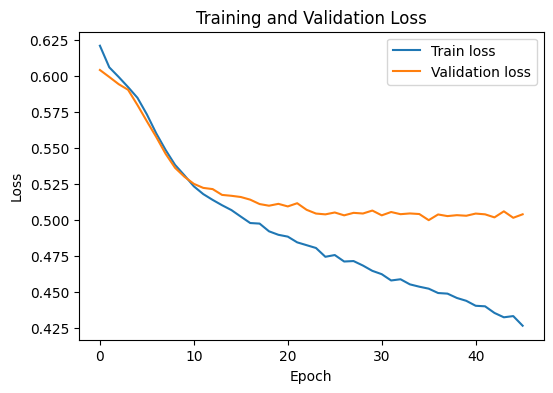

In [36]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

### Training and Validation accuracy over epochs plot

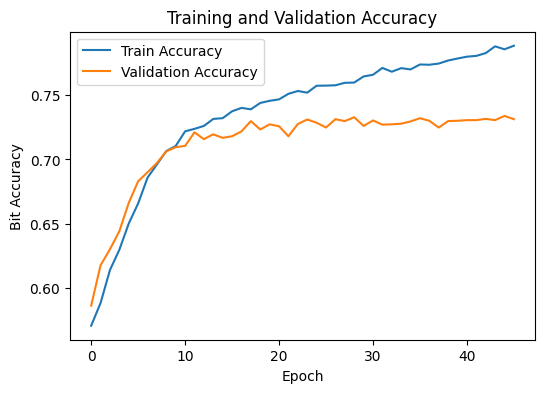

In [37]:
plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Bit Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

### Saving the model

In [38]:
model_path = "./courier_assignment_mlp.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to ./courier_assignment_mlp.pth


### Function to load our model

In [ ]:
def load_trained_model(model_class, N, model_path, device="cpu"):
    # instantiate the model
    model = model_class(N).to(device)

    # load saved weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    
    # set to evaluation mode
    model.eval()
    
    print(f"Model loaded from {model_path} and ready for evaluation.")
    return model

# Example usage:
# loaded_model = load_trained_model(CourierAssignmentMLP, N, "./courier_assignment_mlp.pth", device=device)

## Evaluation, Testing and Visualization